In [1]:
import os
import pandas as pd
#df1 = pd.read_csv(r'刘玲霞3.csv',encoding="utf-8")
from pandasgui import show
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
pd.set_option('display.float_format', lambda x: '%.2f' % x) ## 取消科学计数法显示
pd.set_option('display.max_columns', None)  # 显示所有列# 取消科学计数法显示

C:\Users\hnsj\anaconda3\lib\site-packages\scipy\__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
df = pd.read_csv(r'F:\数据集\20250312\财政一体化22标准数据表\非税收入表_430422.csv',encoding='gbk',low_memory=False)

In [8]:
df.columns

Index(['财政区划代码', '财政区划名称', '预算年度', '缴款书主键', '政府非税收入缴款识别码', '开票日期', '执收单位代码',
       '执收单位名称', '非税收入执收项目识别码', '政府非税收入执收项目代码', '政府非税收入执收项目名称', '政府非税收入类别代码',
       '政府非税收入类别名称', 'INCOME_SORT_CODE', 'INCOME_SORT_NAME', '政府非税收入批准文号',
       '电子非税收入一般缴款书票号', '缴款人全称', '缴款人类型名称', '缴款人代码', '缴款人账号', '缴款人开户银行',
       '收缴标准名称', '应缴金额', '滞纳金金额', '缴款金额', '执收数量', '收款人全称', '收款人账号', '收款账户类型',
       '收款人开户银行', '缴款日期', '入账日期', '收缴方式名称', '非税数据类型', '资金性质代码', '资金性质名称',
       '分成方式名称', '分成标准', '分成比例'],
      dtype='object')

In [4]:
show(df.head(1000))

PandasGUI INFO — pandasgui.gui — Opening PandasGUI


In [16]:
# 从Excel文件加载
#df = pd.read_excel('非税收入数据.xlsx')

# 或从CSV文件加载
# df = pd.read_csv('非税收入数据.csv', encoding='utf-8')

# 然后进行筛选
government_units = df[df['执收单位名称'].str.contains('人民政府', na=False)]

In [17]:
show(government_units)

PandasGUI INFO — pandasgui.gui — Opening PandasGUI


In [13]:
# 按指定字段分组并聚合计算
grouped_df = government_units.groupby(
    ['预算年度','执收单位名称', '政府非税收入执收项目名称']
).agg({
    '缴款金额': 'sum',
    '执收数量': 'sum'
}).reset_index()

# 格式化输出（可选）
grouped_df['缴款金额'] = grouped_df['缴款金额'].apply(lambda x: f'{x:,.2f}')
grouped_df['执收数量'] = grouped_df['执收数量'].apply(lambda x: f'{x:,.0f}')

print("按单位和项目分组的汇总结果：")
print(grouped_df)

# 如果需要保存结果
grouped_df.to_excel('非税收入分组汇总.xlsx', index=False)

按单位和项目分组的汇总结果：
    预算年度       执收单位名称 政府非税收入执收项目名称          缴款金额    执收数量
0   2024   衡南县三塘镇人民政府   公共租赁住房租金收入        240.00       2
1   2024   衡南县三塘镇人民政府     其他一般罚没收入    560,235.17     229
2   2024   衡南县三塘镇人民政府       其他非税收入     85,000.00      26
3   2024   衡南县三塘镇人民政府     国有资产出租收入    300,000.40       2
4   2024   衡南县三塘镇人民政府        污水处理费  1,230,000.00       4
5   2024   衡南县冠市镇人民政府   公共租赁住房租金收入     99,355.00       3
6   2024   衡南县冠市镇人民政府     其他一般罚没收入     82,992.96       5
7   2024   衡南县冠市镇人民政府     国有资产出租收入     24,500.00       3
8   2024   衡南县咸塘镇人民政府     其他一般罚没收入    240,441.23      12
9   2024   衡南县咸塘镇人民政府     国有资产出租收入     44,800.00       1
10  2024   衡南县宝盖镇人民政府   公共租赁住房租金收入    154,565.00      47
11  2024   衡南县宝盖镇人民政府     其他一般罚没收入     80,186.45      12
12  2024   衡南县岐山镇人民政府     其他一般罚没收入    148,246.30      32
13  2024   衡南县松江镇人民政府     其他一般罚没收入    262,982.00      29
14  2024   衡南县柞市镇人民政府     其他一般罚没收入     77,068.00       4
15  2024   衡南县柞市镇人民政府     国有资产出租收入     13,000.00       1
16  2024   衡南县栗江

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号


# 转换日期格式
df['缴款日期'] = pd.to_datetime(df['缴款日期'])
df['入账日期'] = pd.to_datetime(df['入账日期'])

# 查看数据前5行
print("数据预览:")
print(df.head())

# 查看数据基本信息
print("\n数据基本信息:")
print(df.info())

# 描述性统计
print("\n数值型字段描述统计:")
print(df.describe())

数据预览:
      财政区划代码 财政区划名称  预算年度                             缴款书主键  \
0  430422000    衡南县  2024  fa557895dbab40c2a0350875d46e02f8   
1  430422000    衡南县  2024  f26f04b3c2e247c7a80f58cdccbc2e58   
2  430422000    衡南县  2024  dcefff6ec3e849eab0b8ae1910b5646a   
3  430422000    衡南县  2024  ab4e97c6d7a047b8bef6728430888cda   
4  430422000    衡南县  2024  3fe73c8306c84e2abfaf5d9ff79c64dc   

            政府非税收入缴款识别码      开票日期  执收单位代码        执收单位名称   非税收入执收项目识别码  \
0  4304222430810531747X  20241225    5002  衡南县公安局交通警察大队           590   
1  43042224308105317525  20241225    5002  衡南县公安局交通警察大队           590   
2  4304222401084391192X  20241111    5002  衡南县公安局交通警察大队  430000000158   
3  43042224501000057426  20241111   20405   衡南县住房保障服务中心           209   
4  4304222450100005513X  20241104  350112    衡南县宝盖镇人民政府           209   

   政府非税收入执收项目代码 政府非税收入执收项目名称  政府非税收入类别代码 政府非税收入类别名称  INCOME_SORT_CODE  \
0       4011601       驾驶证工本费        1.00  行政事业性收费收入      103040116.00   
1       4011601       驾驶证工本费  

In [59]:
# 按财政区划分析收入
region_income = df.groupby('财政区划名称')['缴款金额'].agg(['sum', 'mean', 'count'])
print("\n按财政区划收入分析:")
print(region_income)

# 按收入类别分析
category_income = df.groupby('政府非税收入类别名称')['缴款金额'].agg(['sum', 'mean', 'count']).sort_values('sum', ascending=False)
print("\n按收入类别分析:")
print(category_income)

# 按执收单位分析
department_income = df.groupby('执收单位名称')['缴款金额'].agg(['sum', 'mean', 'count']).sort_values('sum', ascending=False)
print("\n按执收单位分析:")
print(department_income)

# 按缴款人类型分析
payer_type_income = df.groupby('缴款人类型名称')['缴款金额'].agg(['sum', 'mean', 'count'])
print("\n按缴款人类型分析:")
print(payer_type_income)


按财政区划收入分析:
                sum    mean   count
财政区划名称                             
衡南县    752656060.70 5072.56  148378

按收入类别分析:
                        sum      mean  count
政府非税收入类别名称                                  
行政事业性收费收入      335850893.66   3832.12  87641
罚没收入           179534909.80   3087.02  58158
其他非税收入          30568000.35  15929.13   1919
政府性基金收入         12843408.82 558409.08     23
国有资源（资产）有偿使用收入   6811374.68  46022.80    148

按执收单位分析:
                         sum       mean  count
执收单位名称                                        
衡南县教育局          228877242.32 1064545.31    215
衡南县住房和城乡建设局     192463365.47 3927823.79     49
衡南县公安局          110456100.67   87110.49   1268
中国共产党衡南县纪律检查委员会  19655293.01  145594.76    135
衡南县人力资源和社会保障局    18348180.00 1223212.00     15
...                      ...        ...    ...
衡南县科技和工业信息化局        28870.00    2062.14     14
衡南县教师进修学校           25000.00     260.42     96
衡南县粮油服务中心           20000.00   20000.00      1
中共衡南县委党校             7800.00

In [60]:
# 滞纳金情况分析
penalty_analysis = df[df['滞纳金金额'] > 0]
if not penalty_analysis.empty:
    print("\n滞纳金情况分析:")
    print(penalty_analysis)
    print("\n滞纳金与应缴金额比例:")
    penalty_analysis['滞纳金比例'] = penalty_analysis['滞纳金金额'] / penalty_analysis['应缴金额']
    print(penalty_analysis[['财政区划名称', '执收单位名称', '应缴金额', '滞纳金金额', '滞纳金比例']])
else:
    print("\n没有滞纳金记录")


滞纳金情况分析:
          财政区划代码 财政区划名称  预算年度                             缴款书主键  政府非税收入缴款识别码  \
39530  430422000    衡南县  2024  80e43fd5b05a4dd9b3b08d29615d83fb  4.30422E+19   
51125  430422000    衡南县  2024  ab75b17f554945c69ce9247c52128f36  4.30422E+19   
60889  430422000    衡南县  2024  a545018bde9f49a9924143b49c735d19  4.30422E+19   

           开票日期  执收单位代码    执收单位名称     非税收入执收项目识别码  政府非税收入执收项目代码 政府非税收入执收项目名称  \
39530  20241231   20201  衡南县交通运输局 430000000000.00       5011401       交通罚没收入   
51125  20241230   20201  衡南县交通运输局 430000000000.00       5011401       交通罚没收入   
60889  20241231   20201  衡南县交通运输局 430000000000.00       5011401       交通罚没收入   

       政府非税收入类别代码 政府非税收入类别名称  INCOME_SORT_CODE INCOME_SORT_NAME 政府非税收入批准文号  \
39530        3.00       罚没收入      103050114.00           交通罚没收入          0   
51125        3.00       罚没收入      103050114.00           交通罚没收入          0   
60889        3.00       罚没收入      103050114.00           交通罚没收入          0   

       电子非税收入一般缴款书票号     缴款人全称 缴款人类

C:\Users\OUYIJUN\AppData\Local\Temp\ipykernel_2936\1000542243.py:7: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [14]:
show(df.head(100))

PandasGUI INFO — pandasgui.gui — Opening PandasGUI
C:\Users\OUYIJUN\AppData\Local\Temp\ipykernel_2936\1201370676.py:1: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\OUYIJUN\AppData\Local\Temp\ipykernel_2936\1201370676.py:1: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\OUYIJUN\AppData\Local\Temp\ipykernel_2936\1201370676.py:1: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\OUYIJUN\AppData\Local\Temp\ipykern

C:\Users\OUYIJUN\AppData\Local\Temp\ipykernel_2936\2820338592.py:3: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.




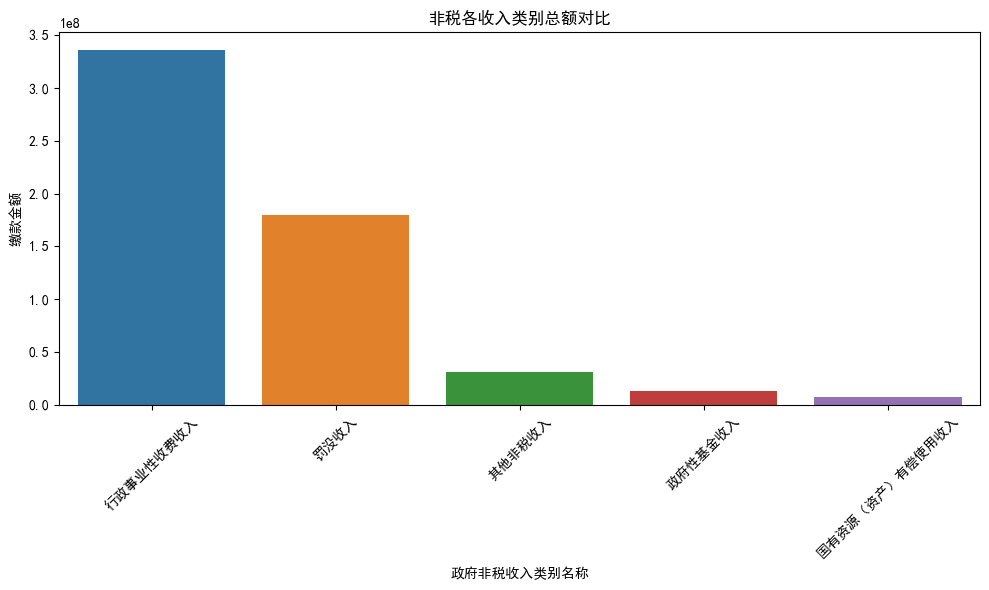

<Figure size 640x480 with 0 Axes>

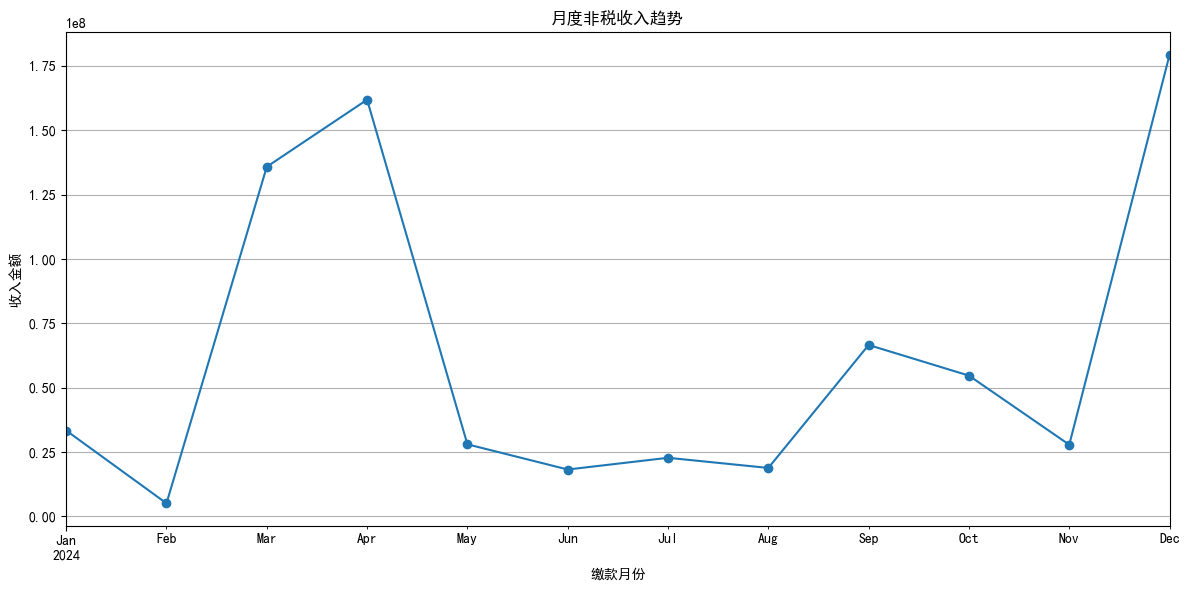

<Figure size 640x480 with 0 Axes>

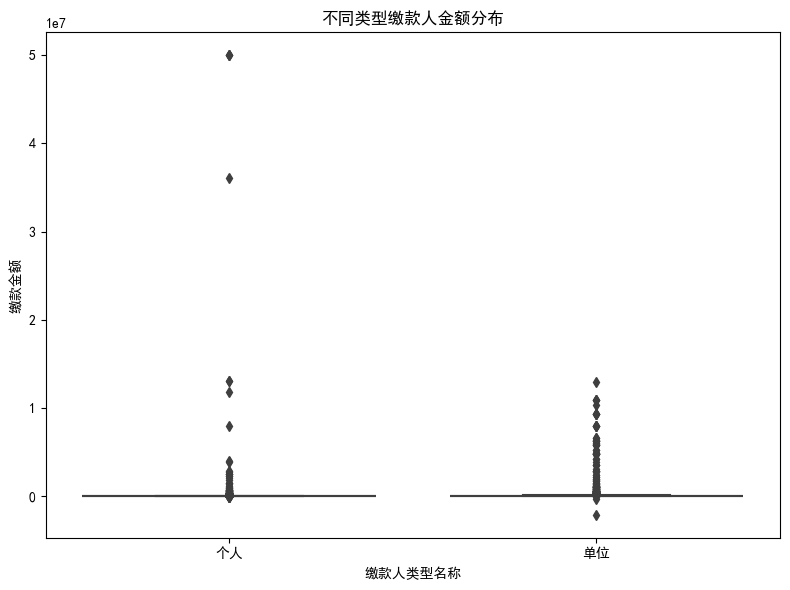

<Figure size 640x480 with 0 Axes>

In [63]:
# 1. 收入类别分布
plt.figure(figsize=(10, 6))
sns.barplot(x='政府非税收入类别名称', y='缴款金额', data=df, estimator=sum, ci=None)
plt.title('非税各收入类别总额对比')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# 保存图形（会自动保存到当前工作目录）
# 再保存图形（show()会清除图形，所以需要重新绘制或使用gcf()）
plt.gcf().savefig('display_and_save.png')
# 2. 月度收入趋势
plt.figure(figsize=(12, 6))
monthly_income.plot(kind='line', marker='o')
plt.title('月度非税收入趋势')
plt.ylabel('收入金额')
plt.grid(True)
plt.tight_layout()
plt.show()
# 保存图形（会自动保存到当前工作目录）
# 再保存图形（show()会清除图形，所以需要重新绘制或使用gcf()）
plt.gcf().savefig('display_and_save2.png')
# 4. 缴款人类型分布
plt.figure(figsize=(8, 6))
sns.boxplot(x='缴款人类型名称', y='缴款金额', data=df)
plt.title('不同类型缴款人金额分布')
plt.tight_layout()
plt.show()
# 再保存图形（show()会清除图形，所以需要重新绘制或使用gcf()）
plt.gcf().savefig('display_and_save3.png')

In [58]:
# 收入预测模型（简单示例）
from sklearn.linear_model import LinearRegression

# 准备时间序列数据
time_series = df.groupby('缴款月份')['缴款金额'].sum().reset_index()
time_series['月份编号'] = range(1, len(time_series)+1)

# 训练简单线性回归模型
model = LinearRegression()
model.fit(time_series[['月份编号']], time_series['缴款金额'])

# 预测未来3个月
future_months = pd.DataFrame({'月份编号': range(len(time_series)+1, len(time_series)+4)})
future_months['预测收入'] = model.predict(future_months[['月份编号']])

print("\n未来3个月收入预测:")
print(future_months)

# 收缴方式分析
payment_method = df.groupby('收缴方式名称')['缴款金额'].agg(['sum', 'count'])
payment_method['平均金额'] = payment_method['sum'] / payment_method['count']
print("\n不同收缴方式分析:")
print(payment_method)


未来3个月收入预测:
   月份编号        预测收入
0    13 79607318.14
1    14 82205161.18
2    15 84803004.22

不同收缴方式分析:
                sum   count    平均金额
收缴方式名称                             
直接缴库   752656060.70  148378 5072.56


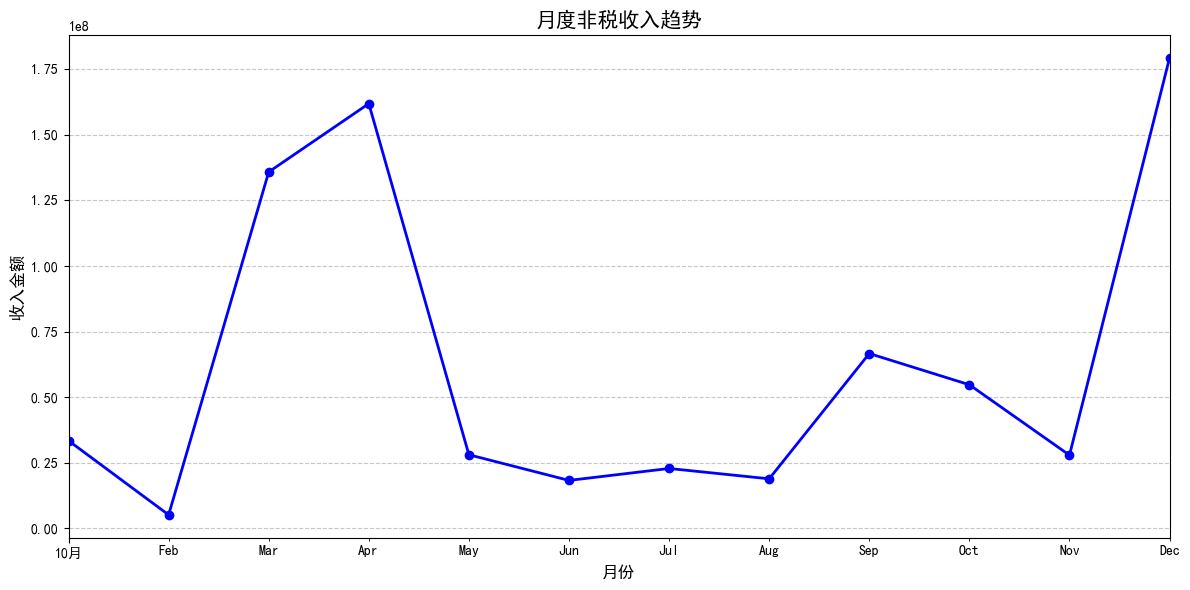

In [55]:
import pandas as pd
import matplotlib.pyplot as plt

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 假设df是您的DataFrame，包含"缴款日期"和"缴款金额"列
# 先将文本格式的日期转换为datetime类型
#df['缴款日期'] = pd.to_datetime(df['缴款日期'], format='%Y%m%d')  # 关键修改点
df['缴款日期'] = pd.to_datetime(df['缴款日期'].astype(str), format='%Y%m%d', errors='coerce')
# 提取年月信息（创建Period对象，方便按月分组）
df['缴款月份'] = df['缴款日期'].dt.to_period('M')

# 按月汇总收入金额
monthly_income = df.groupby('缴款月份')['缴款金额'].sum()

# 绘制月度趋势图
plt.figure(figsize=(12, 6))
monthly_income.plot(kind='line', marker='o', color='b', linewidth=2)
plt.title('月度非税收入趋势', fontsize=15)
plt.ylabel('收入金额', fontsize=12)
plt.xlabel('月份', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# 优化x轴标签显示
if len(monthly_income) > 12:  # 如果数据跨年，显示年月
    plt.xticks(rotation=45)
    plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m'))
else:  # 如果只有一年数据，只显示月份
    plt.xticks(rotation=0)
    plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%m月'))

plt.tight_layout()
plt.show()

In [46]:
show(df['缴款月份'])

PandasGUI INFO — pandasgui.gui — Opening PandasGUI
C:\Users\OUYIJUN\AppData\Local\Temp\ipykernel_2936\366299858.py:1: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\OUYIJUN\AppData\Local\Temp\ipykernel_2936\366299858.py:1: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\OUYIJUN\AppData\Local\Temp\ipykernel_2936\366299858.py:1: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\OUYIJUN\AppData\Local\Temp\ipykernel_

In [38]:
# 查看原始日期列的样本和前几行
print("原始日期数据示例:")
print(df['缴款日期'].head())

# 检查数据类型
print("\n日期列数据类型:", df['缴款日期'].dtype)

# 检查是否有空值
print("\n空值数量:", df['缴款日期'].isna().sum())

原始日期数据示例:
0    20241225
1    20241225
2    20241111
3    20241111
4    20241104
Name: 缴款日期, dtype: int64

日期列数据类型: int64

空值数量: 0


In [39]:
# 方法1：先确保转换为字符串，再转换日期
df['缴款日期'] = pd.to_datetime(df['缴款日期'].astype(str), format='%Y%m%d', errors='coerce')

# 方法2：如果方法1无效，尝试不指定格式，让pandas自动推断
# df['缴款日期'] = pd.to_datetime(df['缴款日期'].astype(str), errors='coerce')

# 检查转换后的日期
print("\n转换后的日期示例:")
print(df['缴款日期'].head())

# 检查转换失败的记录
failed_conversion = df[df['缴款日期'].isna()]
if not failed_conversion.empty:
    print("\n转换失败的记录:")
    print(failed_conversion[['缴款日期']])


转换后的日期示例:
0   2024-12-25
1   2024-12-25
2   2024-11-11
3   2024-11-11
4   2024-11-04
Name: 缴款日期, dtype: datetime64[ns]


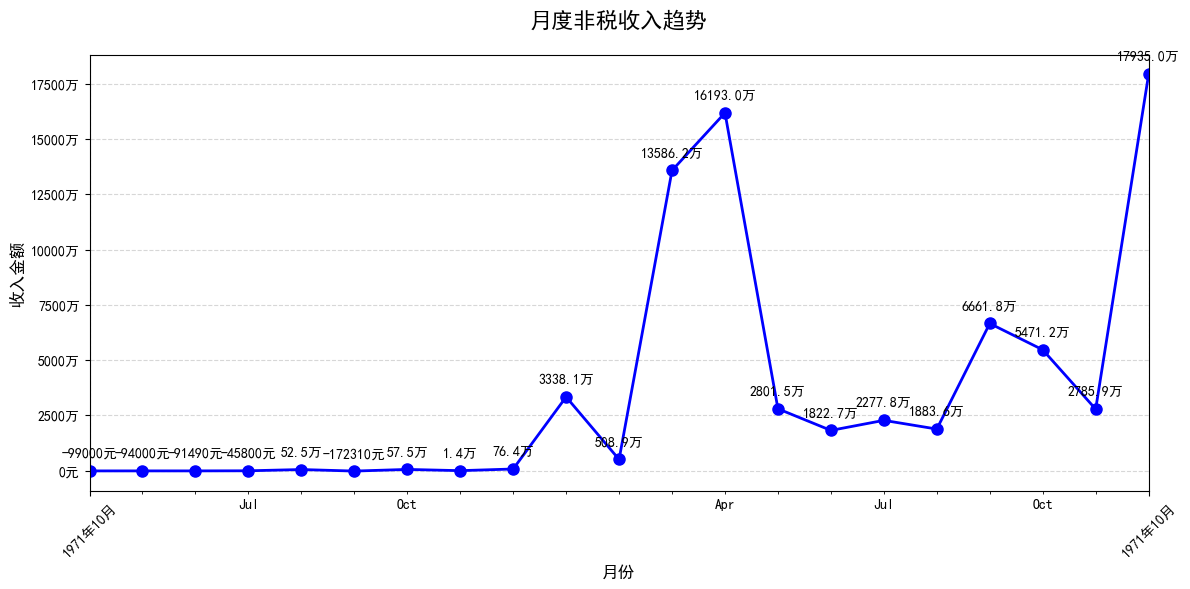

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 1. 日期转换
df['缴款日期'] = pd.to_datetime(df['缴款日期'].astype(str), format='%Y%m%d', errors='coerce')
df = df.dropna(subset=['缴款日期'])  # 删除无效日期

# 2. 按月分组
df['缴款月份'] = df['缴款日期'].dt.to_period('M')
monthly_income = df.groupby('缴款月份')['缴款金额'].sum()

# 3. 准备绘图数据（将Period转换为Timestamp）
monthly_income.index = monthly_income.index.to_timestamp()

# 4. 创建图形
plt.figure(figsize=(12, 6))
ax = plt.gca()

# 5. 格式化数值显示（以"万"为单位）
def yuan_to_wan(x, pos):
    return f'{x/10000:.0f}万' if x >= 10000 else f'{x:.0f}元'

ax.yaxis.set_major_formatter(FuncFormatter(yuan_to_wan))

# 6. 绘制折线图
monthly_income.plot(kind='line', marker='o', color='b', linewidth=2, markersize=8, ax=ax)

# 7. 设置中文月份标签
months_chinese = ['1月', '2月', '3月', '4月', '5月', '6月', 
                 '7月', '8月', '9月', '10月', '11月', '12月']

if len(monthly_income) <= 12:  # 单年数据
    ax.set_xticks(monthly_income.index)
    ax.set_xticklabels([months_chinese[date.month-1] for date in monthly_income.index])
else:  # 多年数据
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))  # 每3个月一个刻度
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y年%m月'))
    plt.xticks(rotation=45)

# 8. 添加数据标签（在点上显示具体数值）
for x, y in zip(monthly_income.index, monthly_income.values):
    label = f'{y/10000:.1f}万' if y >= 10000 else f'{y:.0f}元'
    ax.annotate(label, (x, y), textcoords="offset points", xytext=(0,10), ha='center')

# 9. 设置标题和网格
plt.title('月度非税收入趋势', fontsize=16, pad=20)
plt.ylabel('收入金额', fontsize=12)
plt.xlabel('月份', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# 10. 调整布局
plt.tight_layout()
plt.show()

In [2]:
df = pd.read_excel(r"F:\数据集\何志军\单位指标-导出的数据 20241231161751.xlsx")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15897 entries, 0 to 15896
Data columns (total 42 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   序号          15897 non-null  int64  
 1   指标状态        15897 non-null  object 
 2   指标单据类型      15897 non-null  object 
 3   来源文号        1590 non-null   object 
 4   本级指标文号      15897 non-null  object 
 5   资金主管处室      15897 non-null  object 
 6   业务处室        15897 non-null  object 
 7   单位名称        15897 non-null  object 
 8   资金性质        15897 non-null  object 
 9   支出功能科目      15897 non-null  object 
 10  政府经济科目      15897 non-null  object 
 11  部门经济科目      15879 non-null  object 
 12  指标金额(元)     15897 non-null  float64
 13  已申请支付金额(元)  15897 non-null  float64
 14  实际下达数（元）    15897 non-null  float64
 15  调剂金额(元)     15897 non-null  float64
 16  追减金额(元)     15897 non-null  float64
 17  冻结金额(元)     15897 non-null  float64
 18  指标余额(元)》    15897 non-null  float64
 19  指标可用金额(元)   15897 non-nul

In [4]:
df.columns

Index(['序号', '指标状态', '指标单据类型', '来源文号', '本级指标文号', '资金主管处室', '业务处室', '单位名称',
       '资金性质', '支出功能科目', '政府经济科目', '部门经济科目', '指标金额(元)', '已申请支付金额(元)',
       '实际下达数（元）', '调剂金额(元)', '追减金额(元)', '冻结金额(元)', '指标余额(元)》', '指标可用金额(元)',
       '预算项目', '项目类别', '指标说明', '预算级次', '指标流向', '指标类型 ', '预算来源', '所属专项',
       '是否政府采购', '工资标识', '扶贫标识', '是否补贴到人到企业', '支付方式', '经办人', '发文日期', '创建日期',
       '拨款方式', '一般性支出标识', '三公经费标识', '热点分类', '摘要', '最终生效时间'],
      dtype='object')

In [5]:
df.head()

,序号,指标状态,指标单据类型,来源文号,本级指标文号,资金主管处室,业务处室,单位名称,资金性质,支出功能科目,政府经济科目,部门经济科目,指标金额(元),已申请支付金额(元),实际下达数（元）,调剂金额(元),追减金额(元),冻结金额(元),指标余额(元)》,指标可用金额(元),预算项目,项目类别,指标说明,预算级次,指标流向,指标类型,预算来源,所属专项,是否政府采购,工资标识,扶贫标识,是否补贴到人到企业,支付方式,经办人,发文日期,创建日期,拨款方式,一般性支出标识,三公经费标识,热点分类,摘要,最终生效时间
0,1,已终审,单位指标追加单,湘财行指〔2024〕0032号,清财预B〔2024〕270号,01 行政政法股,01 行政政法股,116001 衡南县市场监督管理局,111 一般公共预算资金,2013899 其他市场监督管理事务,50299 其他商品和服务支出,30299 其他商品和服务支出,20000.00,0.00,20000.00,0.00,0.00,0.00,20000.00,0.00,食品安全考核工作经费,3 特定目标类,衡南县市场监督管理局,2 省级,1 本级,21 当年预算,222 省级专项,NaN,否,否,NaN,NaN,1 国库集中支付,陈宏伟,2024-12-02,2024-12-02,NaN,NaN,NaN,000 非“三保”支出;,NaN,2024-12-03
1,2,已终审,单位指标调剂单,NaN,年初预算项目〔2024〕0001号,02 社保股,02 社保股,207001 衡南县退役军人事务局,111 一般公共预算资金,2082899 其他退役军人事务管理支出,59999 其他支出,39999 其他支出,1100000.00,1100000.00,1100000.00,0.00,0.00,0.00,0.00,0.00,优抚对象补助经费,3 特定目标类,社保股/部分优抚对象丧葬,5 县（区）级,1 本级,21 当年预算,111 年初安排,NaN,否,否,NaN,NaN,1 国库集中支付,廖晓艳,2024-03-20,2024-11-14,NaN,NaN,NaN,NaN,社保股/部分优抚对象丧葬,2024-11-14
2,3,已终审,单位指标调剂单,NaN,年初预算项目〔2024〕0001号,02 社保股,02 社保股,207001 衡南县退役军人事务局,111 一般公共预算资金,2082899 其他退役军人事务管理支出,59999 其他支出,39999 其他支出,1500000.00,1500000.00,1500000.00,0.00,0.00,0.00,0.00,0.00,优抚对象补助经费,3 特定目标类,社保股/伤残军人护理费,5 县（区）级,1 本级,21 当年预算,111 年初安排,NaN,否,否,NaN,NaN,1 国库集中支付,廖晓艳,2024-03-20,2024-11-14,NaN,NaN,NaN,NaN,社保股/伤残军人护理费,2024-11-14
3,4,已终审,单位指标调剂单,NaN,年初预算项目〔2024〕0001号,02 社保股,02 社保股,207001 衡南县退役军人事务局,111 一般公共预算资金,2082899 其他退役军人事务管理支出,59999 其他支出,39999 其他支出,7210000.00,7165148.60,7210000.00,0.00,0.00,0.00,44851.40,0.00,优抚对象补助经费,3 特定目标类,（调剂）社保股/优抚对象补助资金,5 县（区）级,1 本级,21 当年预算,111 年初安排,NaN,否,否,NaN,NaN,1 国库集中支付,廖晓艳,2024-03-20,2024-11-14,NaN,NaN,NaN,NaN,社保股/优抚对象补助资金,2024-11-14
4,5,已终审,单位指标调剂单,湘财预〔2023〕0394号,清财预B〔2024〕0052号,05 教科文股,05 教科文股,516001 衡南县融媒体中心,111 一般公共预算资金,2079999 其他文化旅游体育与传媒支出,50599 其他对事业单位补助,31299 其他对企业补助,312000.00,0.00,312000.00,0.00,0.00,0.00,312000.00,312000.00,中央广播电视节目无线覆盖运维-1-复制项目,3 特定目标类,提前下达2024年中央支持地方公共文化服务体系建设补助资金预算的通知,1 中央级,1 本级,21 当年预算,221 一般性转移支付,NaN,否,否,NaN,NaN,1 国库集中支付,钟常青,2024-02-19,2024-11-05,NaN,NaN,NaN,NaN,NaN,2024-11-05


In [9]:
# 定义要查询的文号列表
target_documents = ['湘财预〔2023〕0232号',
'湘财综指〔2023〕0017号',
'湘财预〔2023〕0286号',
'湘财综指〔2022〕0022号',
'湘财文指〔2022〕0044号',
'湘财文指〔2022〕0012号',
'湘财预〔2022〕0345号',
'湘财文指〔2023〕0039号',
'湘财综指〔2023〕0010号',
'湘财综指〔2023〕0019号'

]

# 使用 isin() 方法查询匹配的行
result = df[df['来源文号'].isin(target_documents)]

# 显示查询结果
print(result)
show(result)



pattern = '湘财文指|湘财预'  # 用 | 表示 OR 条件
result = df[df['本级指标文号'].str.contains(pattern, na=False, regex=True)]

PandasGUI INFO — pandasgui.gui — Opening PandasGUI


          序号 指标状态   指标单据类型             来源文号           本级指标文号    资金主管处室  \
363      364  已终审  单位指标追加单  湘财综指〔2023〕0019号  清财预C〔2024〕0001号  06 综合计划股   
396      397  已终审  单位指标追加单  湘财综指〔2023〕0010号  清财预D〔2024〕0386号  06 综合计划股   
580      581  已终审  单位指标追加单  湘财综指〔2023〕0010号  清财预D〔2024〕0386号  06 综合计划股   
1392    1393  已终审  单位指标追加单  湘财综指〔2022〕0022号  清财预D〔2024〕0247号  06 综合计划股   
1476    1477  已终审  单位指标追加单  湘财综指〔2023〕0019号  清财预C〔2024〕0001号  06 综合计划股   
...      ...  ...      ...              ...              ...       ...   
14908  14909  已终审  单位指标追加单  湘财综指〔2023〕0010号  清财预D〔2024〕0386号  06 综合计划股   
14909  14910  已终审  单位指标追加单  湘财综指〔2023〕0010号  清财预D〔2024〕0386号  06 综合计划股   
14910  14911  已终审  单位指标追加单  湘财综指〔2023〕0010号  清财预D〔2024〕0386号  06 综合计划股   
14966  14967  已终审  单位指标追加单  湘财综指〔2023〕0019号  清财预C〔2024〕0001号  06 综合计划股   
15632  15633  已终审  单位指标追加单  湘财综指〔2023〕0019号  清财预C〔2024〕0001号  06 综合计划股   

          业务处室                 单位名称           资金性质                  支出功能科目  \
363     13 预算股    919001 衡南县三塘镇人民

In [10]:

# 定义要查询的文号列表
target_documents = ['湘财文指〔2022〕0044号',
'湘财预〔2022〕0125号',
'湘财预〔2022〕0129号',
'湘财文指〔2022〕0019号',
'湘财文指〔2022〕0030号',
'湘财文指〔2022〕0012号',
'湘财预〔2022〕0345号']

# 使用 isin() 方法查询匹配的行
result = df[df['来源文号'].isin(target_documents)]

# 显示查询结果
print(result)
show(result)

PandasGUI INFO — pandasgui.gui — Opening PandasGUI


          序号 指标状态        指标单据类型             来源文号           本级指标文号   资金主管处室  \
12442  12443  已终审  单位指标导入（上补数据）  湘财文指〔2022〕0012号  清财预D〔2024〕0001号  05 教科文股   
12461  12462  已终审  单位指标导入（上补数据）   湘财预〔2022〕0345号  清财预D〔2024〕0001号  05 教科文股   
12467  12468  已终审  单位指标导入（上补数据）  湘财文指〔2022〕0044号  清财预D〔2024〕0001号  05 教科文股   

          业务处室                 单位名称          资金性质                 支出功能科目  \
12442  05 教科文股  501001 衡南县文体广电新闻出版局  111 一般公共预算资金           2070204 文物保护   
12461  05 教科文股  501001 衡南县文体广电新闻出版局  111 一般公共预算资金  2079999 其他文化旅游体育与传媒支出   
12467  05 教科文股  501001 衡南县文体广电新闻出版局  111 一般公共预算资金  2079999 其他文化旅游体育与传媒支出   

                政府经济科目           部门经济科目    指标金额(元)  已申请支付金额(元)   实际下达数（元）  \
12442  50299 其他商品和服务支出  30299 其他商品和服务支出  443600.00   443600.00  443600.00   
12461  50599 其他对事业单位补助    31299 其他对企业补助 2605419.00  2345419.00 2605419.00   
12467  50299 其他商品和服务支出  30299 其他商品和服务支出  150000.00        0.00  150000.00   

       调剂金额(元)  追减金额(元)  冻结金额(元)  指标余额(元)》  指标可用金额(元)  预算项目     项目类别  \
1